# Solved Exam Notebook — 7th of June 2024

Course: **1MS041 Introduction to Data Science / Introduktion till dataanalys**

This notebook includes the **whole exam questions first**, then the **solved code answers with steps, comments, plots, and explanations**.

> Put your anonymous exam ID below.

In [ ]:
examID = "XXX"

## Problem 1 — Full Question

Maximum Points = 14

In this problem you will do rejection sampling from complicated distributions, you will also be using your samples to compute certain integrals, a method known as Monte Carlo integration. Keep in mind that choosing a good sampling distribution is often key to avoid too much rejection.

1. **[4p]** Fill in the remaining part of the function `problem1_rejection` in order to produce samples from the below density using rejection sampling:

\[
f[x] = Cx^{0.2}(1-x)^{1.3}
\]

for \(0 \le x \le 1\), where \(C\) is a value such that \(f\) above is a density, i.e. integrates to one. Hint: you do not need to know the value of \(C\) to perform rejection sampling.

2. **[2p]** Produce 100000 samples, use fewer if it takes too long, and put the answer in `problem1_samples` from the above distribution and plot the histogram.

3. **[2p]** Define \(X\) as a random variable with the density given in part 1. Denote

\[
Y = \sin(10X)
\]

and use the above 100000 samples to estimate

\[
\mathbb{E}[Y]
\]

and store the result in `problem1_expectation`.

4. **[2p]** Use Hoeffding's inequality to produce a 95% confidence interval of the expectation above and store the result as a tuple in the variable `problem1_interval`.

5. **[4p]** Can you calculate an approximation of the value of \(C\) from part 1 using random samples? Provide a plot of the histogram from part 2 together with the true density as a curve, recall that this requires the value of \(C\). Explain what method you used and what answer you got.

### Problem 1 — Solution idea

The unnormalised density is

\[
h(x)=x^{0.2}(1-x)^{1.3},\quad 0\le x\le 1.
\]

Use a **Uniform(0,1)** proposal. Since the proposal density is \(g(x)=1\), accept a proposed \(x\) with probability \(h(x)/M\), where \(M\) is the maximum of \(h(x)\). The maximum of \(x^a(1-x)^b\) happens at \(x=a/(a+b)\).

In [ ]:
# Problem 1 imports
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [1]:
# Part 1
def problem1_rejection(n_samples=1):
    # Rejection sampler for density proportional to:
    # h(x) = x^0.2 * (1-x)^1.3, 0 <= x <= 1

    n_samples = int(n_samples)
    samples = []

    def h(x):
        return (x ** 0.2) * ((1 - x) ** 1.3)

    # Maximum of x^a(1-x)^b occurs at a/(a+b)
    a = 0.2
    b = 1.3
    x_star = a / (a + b)
    M = h(x_star)

    batch_size = max(1000, n_samples)

    while len(samples) < n_samples:
        x = np.random.uniform(0, 1, size=batch_size)
        u = np.random.uniform(0, 1, size=batch_size)

        accepted = x[u <= h(x) / M]
        samples.extend(accepted.tolist())

    return np.array(samples[:n_samples])

In [ ]:
# Part 2
problem1_samples = problem1_rejection(100000)

plt.figure(figsize=(8, 5))
plt.hist(problem1_samples, bins=60, density=True, alpha=0.6, edgecolor="black")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Histogram of rejection samples")
plt.show()

problem1_samples[:10], problem1_samples.shape

In [ ]:
# Part 3
Y_samples = np.sin(10 * problem1_samples)
problem1_expectation = float(np.mean(Y_samples))

problem1_expectation

In [ ]:
# Part 4
# Hoeffding 95% confidence interval for E[sin(10X)].
# Since sin(10X) is bounded in [-1, 1], b-a = 2.

delta = 0.05
n = len(Y_samples)
epsilon = 2 * np.sqrt(np.log(2 / delta) / (2 * n))

problem1_interval = (
    float(problem1_expectation - epsilon),
    float(problem1_expectation + epsilon)
)

problem1_interval

In [ ]:
# Part 5
# Estimate C using Monte Carlo integration.
# C = 1 / integral_0^1 h(x) dx.
# If U ~ Uniform(0,1), then integral_0^1 h(x) dx = E[h(U)].

def h_problem1(x):
    return (x ** 0.2) * ((1 - x) ** 1.3)

mc_n = 1_000_000
U = np.random.uniform(0, 1, size=mc_n)
integral_estimate = np.mean(h_problem1(U))
problem1_C = float(1 / integral_estimate)

problem1_C

In [ ]:
# Part 5 plot
x_grid = np.linspace(0, 1, 1000)
true_density_estimated = problem1_C * h_problem1(x_grid)

plt.figure(figsize=(8, 5))
plt.hist(problem1_samples, bins=60, density=True, alpha=0.6, edgecolor="black", label="Sample histogram")
plt.plot(x_grid, true_density_estimated, linewidth=2, label="Estimated true density")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Histogram with estimated true density")
plt.legend()
plt.show()

### Problem 1 Part 5 — Free-text explanation

To estimate \(C\), I used Monte Carlo integration. The unnormalised density is

\[
h(x)=x^{0.2}(1-x)^{1.3}.
\]

The normalising constant is

\[
C=\frac{1}{\int_0^1 h(x)\,dx}.
\]

If \(U\sim \mathrm{Uniform}(0,1)\), then

\[
\int_0^1 h(x)\,dx = \mathbb{E}[h(U)].
\]

So I generated many uniform random values \(U_i\), approximated the integral by the average of \(h(U_i)\), and then took the inverse. The answer is stored in `problem1_C`.

In [ ]:
# Local test for Problem 1
try:
    assert(isinstance(problem1_rejection(10), np.ndarray))
    print("Good, problem1_rejection returns a numpy array")
except:
    print("Try again. You should return a numpy array from problem1_rejection")

try:
    assert(isinstance(problem1_samples, np.ndarray))
    print("Good, problem1_samples is a numpy array")
except:
    print("Try again. problem1_samples is not a numpy array")

try:
    assert(isinstance(problem1_expectation, float))
    print("Good, problem1_expectation is a float")
except:
    print("Try again. problem1_expectation is not a float")

try:
    assert(isinstance(problem1_interval, list) or isinstance(problem1_interval, tuple))
    assert(len(problem1_interval) == 2)
    print("Good, problem1_interval is a tuple/list of length 2")
except Exception as e:
    print(e)

## Problem 2 — Full Question

Maximum Points = 13

Let us build a proportional model

\[
P(Y = 1 \mid X)=G(\beta_0+\beta\cdot X)
\]

where \(G\) is the logistic function, for the spam vs not spam data. Here we assume that the features are presence vs not presence of a word. Let \(X_1, X_2, X_3\) denote the presence (1) or absence (0) of the words **"free"**, **"prize"**, **"win"**.

1. **[2p]** Load the file `data/spam.csv` and create two numpy arrays, `problem2_X` which has shape `(n_emails,3)` where each feature in `problem2_X` corresponds to \(X_1, X_2, X_3\), and `problem2_Y` which has shape `(n_emails,)` and consists of a 1 if the email is spam and 0 if it is not. Split this data into train-calibration-test sets where we have the split 40%, 20%, 40%.

2. **[4p]** Follow the calculation from the lecture notes where we derive the logistic regression and implement the final loss function inside the class `ProportionalSpam`.

3. **[4p]** Train the model `problem2_ps` on the training data. Calibrate the probabilities output from the model. Start by creating `problem2_X_pred` with shape `(n_samples,1)` which consists of the predictions of `problem2_ps` on the calibration dataset. Then train a calibration model using `sklearn.tree.DecisionTreeRegressor`, store it in `problem2_calibrator`.

4. **[3p]** Use the trained model `problem2_ps` and the calibrator `problem2_calibrator` to make final predictions on the testing data, store the prediction in `problem2_final_predictions`. Compute the \(0-1\) test-loss and store it in `problem2_01_loss` and provide a 99% confidence interval of it, stored in `problem2_interval`.

### Problem 2 — Solution idea

For logistic regression, with \(z_i=\beta_0+\beta\cdot x_i\), the average negative log-likelihood is

\[
\frac{1}{n}\sum_{i=1}^{n}\left[\log(1+\exp(z_i))-y_i z_i\right].
\]

For the \(0-1\) loss confidence interval, the loss is bounded in \([0,1]\), so Hoeffding gives half-width

\[
\epsilon=\sqrt{\frac{\log(2/\delta)}{2n}},
\]

with \(\delta=0.01\) for 99% confidence.

In [ ]:
# Problem 2 imports
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)

In [ ]:
# Part 1
spam_df = pd.read_csv("data/spam.csv")

# Robust feature-column detection
feature_cols = []
for target_name in ["free", "prize", "win"]:
    matches = [c for c in spam_df.columns if c.lower().strip() == target_name]
    if matches:
        feature_cols.append(matches[0])

if len(feature_cols) != 3:
    # fallback: assume first three columns are the word features
    feature_cols = list(spam_df.columns[:3])

# Robust target-column detection
target_col = None
for name in ["spam", "is_spam", "label", "Y", "y"]:
    matches = [c for c in spam_df.columns if c.lower().strip() == name.lower()]
    if matches:
        target_col = matches[0]
        break

if target_col is None:
    # fallback: assume last column is target
    target_col = spam_df.columns[-1]

problem2_X = spam_df[feature_cols].values
problem2_Y = spam_df[target_col].values.astype(int)

# Split 40% train, 20% calibration, 40% test.
problem2_X_train, X_tmp, problem2_Y_train, Y_tmp = train_test_split(
    problem2_X, problem2_Y, train_size=0.4, random_state=42, shuffle=True
)

problem2_X_calib, problem2_X_test, problem2_Y_calib, problem2_Y_test = train_test_split(
    X_tmp, Y_tmp, train_size=1/3, random_state=42, shuffle=True
)

print(problem2_X_train.shape, problem2_X_calib.shape, problem2_X_test.shape,
      problem2_Y_train.shape, problem2_Y_calib.shape, problem2_Y_test.shape)

In [ ]:
# Part 2
class ProportionalSpam(object):
    def __init__(self):
        self.coeffs = None
        self.result = None

    def loss(self, X, Y, coeffs):
        # Average logistic negative log-likelihood.
        X = np.asarray(X)
        Y = np.asarray(Y)

        z = np.dot(X, coeffs[1:]) + coeffs[0]
        loss_values = np.logaddexp(0, z) - Y * z
        return float(np.mean(loss_values))

    def fit(self, X, Y):
        import numpy as np
        from scipy import optimize

        opt_loss = lambda coeffs: self.loss(X, Y, coeffs)
        initial_arguments = np.zeros(shape=X.shape[1] + 1)
        self.result = optimize.minimize(opt_loss, initial_arguments, method="cg")
        self.coeffs = self.result.x

    def predict(self, X):
        if self.coeffs is not None:
            G = lambda x: np.exp(x) / (1 + np.exp(x))
            return np.round(10 * G(np.dot(X, self.coeffs[1:]) + self.coeffs[0])) / 10
        else:
            raise ValueError("Model has not been fitted yet.")

In [ ]:
# Local loss test from the exam
try:
    test_instance = ProportionalSpam()
    test_loss = test_instance.loss(
        np.array([[1, 0, 1], [0, 1, 1]]),
        np.array([1, 0]),
        np.array([1.2, 0.4, 0.3, 0.9])
    )
    assert (np.abs(test_loss - 1.2828629432232497) < 1e-6)
    print("Your loss was correct for a test point")
except:
    print("Your loss was not correct on a test point")
    print("Computed loss:", test_loss)

In [ ]:
# Part 3
problem2_ps = ProportionalSpam()
problem2_ps.fit(problem2_X_train, problem2_Y_train)

problem2_X_pred = problem2_ps.predict(problem2_X_calib).reshape(-1, 1)

problem2_calibrator = DecisionTreeRegressor(random_state=42)
problem2_calibrator.fit(problem2_X_pred, problem2_Y_calib)

problem2_X_pred[:10], problem2_X_pred.shape

In [ ]:
# Part 4
# These are calibrated predicted probabilities on the testing data
test_uncalibrated_predictions = problem2_ps.predict(problem2_X_test).reshape(-1, 1)
problem2_final_predictions = problem2_calibrator.predict(test_uncalibrated_predictions)

# Convert predicted probabilities to decisions using the Bayes classifier threshold 0.5
problem2_final_decisions = (problem2_final_predictions >= 0.5).astype(int)

problem2_01_loss = float(np.mean(problem2_final_decisions != problem2_Y_test))

# 99% confidence interval using Hoeffding
delta = 0.01
n = len(problem2_Y_test)
epsilon = np.sqrt(np.log(2 / delta) / (2 * n))

problem2_interval = (
    float(max(0, problem2_01_loss - epsilon)),
    float(min(1, problem2_01_loss + epsilon))
)

problem2_01_loss, problem2_interval

## Problem 3 — Full Question

Maximum Points = 13

Consider the following four Markov chains, answer each question for all chains:

1. **[2p]** What is the transition matrix?

2. **[2p]** Is the Markov chain irreducible?

3. **[3p]** Is the Markov chain aperiodic? What is the period for each state? Hint: Recall our definition of period. Let

\[
T := \{t\in \mathbb{N}: P^t(x,x)>0\}
\]

and the greatest common divisor of \(T\) is the period.

4. **[3p]** Does the Markov chain have a stationary distribution, and if so, what is it?

5. **[3p]** Is the Markov chain reversible?

The diagrams are interpreted using state order \(A,B,C,D,\dots\), corresponding to index \(0,1,2,3,\dots\).

### Markov chain diagrams from the exam

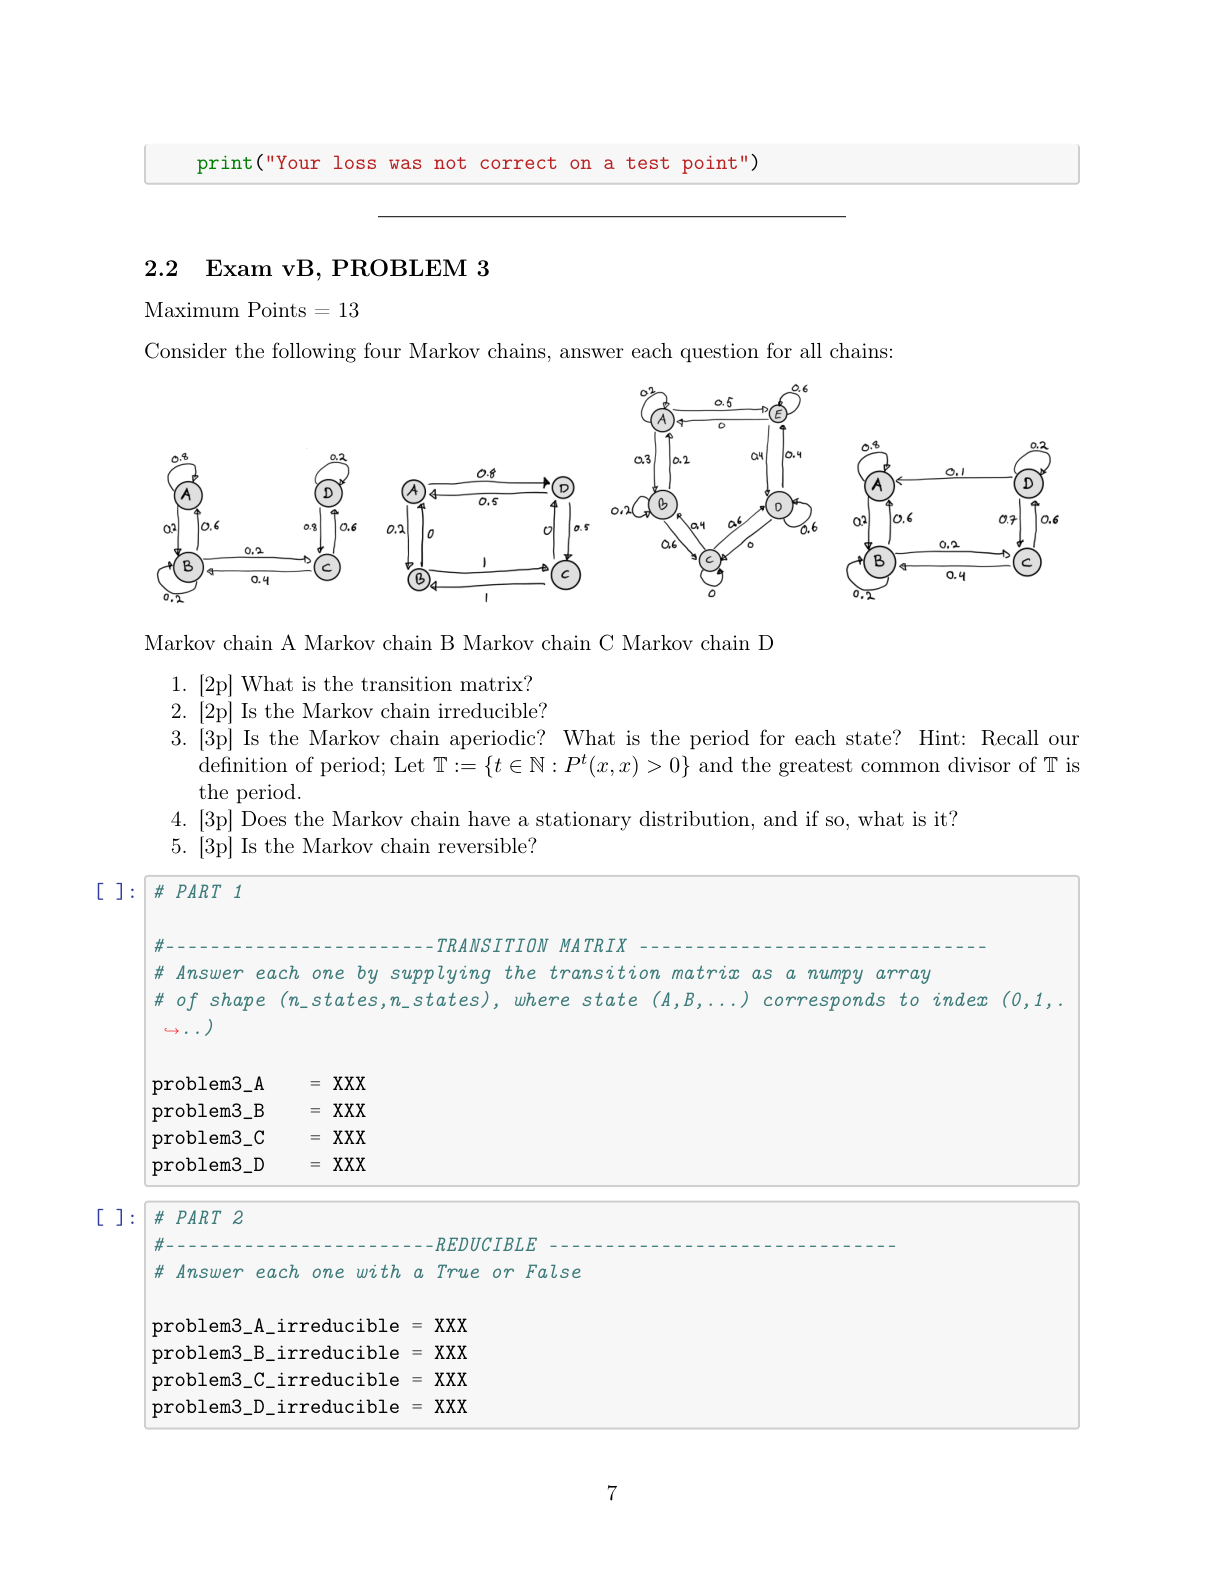

### Problem 3 — Solution idea

A transition matrix has rows that sum to 1. Entry \(P_{ij}\) means probability of moving from state \(i\) to state \(j\).

A finite Markov chain always has at least one stationary distribution. We calculate it by solving

\[
\pi P = \pi,\qquad \sum_i \pi_i = 1.
\]

Reversibility is checked using detailed balance:

\[
\pi_i P_{ij}=\pi_j P_{ji}
\]

for all states \(i,j\).

In [ ]:
# Problem 3 imports
import numpy as np
import math

In [ ]:
# PART 1
# ------------------------ TRANSITION MATRIX -------------------------------
# State order:
# Chain A, B, D: A, B, C, D
# Chain C: A, B, C, D, E

problem3_A = np.array([
    [0.8, 0.2, 0.0, 0.0],
    [0.6, 0.2, 0.2, 0.0],
    [0.0, 0.4, 0.0, 0.6],
    [0.0, 0.0, 0.8, 0.2]
])

problem3_B = np.array([
    [0.0, 0.2, 0.0, 0.8],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0]
])

problem3_C = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.2, 0.2, 0.6, 0.0, 0.0],
    [0.0, 0.4, 0.0, 0.6, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.4],
    [0.0, 0.0, 0.0, 0.4, 0.6]
])

problem3_D = np.array([
    [0.8, 0.2, 0.0, 0.0],
    [0.6, 0.2, 0.2, 0.0],
    [0.0, 0.4, 0.0, 0.6],
    [0.1, 0.0, 0.7, 0.2]
])

print("Row sums:")
print("A:", problem3_A.sum(axis=1))
print("B:", problem3_B.sum(axis=1))
print("C:", problem3_C.sum(axis=1))
print("D:", problem3_D.sum(axis=1))

In [ ]:
# Helper functions

def communication_matrix(P):
    P = np.asarray(P)
    n = P.shape[0]
    adjacency = P > 1e-12
    reach = adjacency.copy()

    for k in range(n):
        for i in range(n):
            for j in range(n):
                reach[i, j] = reach[i, j] or (reach[i, k] and reach[k, j])
    return reach

def is_irreducible(P):
    return bool(communication_matrix(P).all())

def state_periods(P, max_power=100):
    P = np.asarray(P)
    n = P.shape[0]
    periods = np.zeros(n, dtype=int)
    power = np.eye(n)

    for t in range(1, max_power + 1):
        power = power @ P
        for i in range(n):
            if power[i, i] > 1e-12:
                if periods[i] == 0:
                    periods[i] = t
                else:
                    periods[i] = math.gcd(periods[i], t)

    return periods

def stationary_distribution(P):
    P = np.asarray(P)
    eigenvalues, eigenvectors = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(eigenvalues - 1))
    pi = np.real(eigenvectors[:, idx])

    if np.sum(pi) < 0:
        pi = -pi

    pi[np.abs(pi) < 1e-12] = 0
    pi = pi / np.sum(pi)
    return pi

def is_reversible(P, pi):
    P = np.asarray(P)
    pi = np.asarray(pi)
    return bool(np.allclose(pi[:, None] * P, pi[None, :] * P.T, atol=1e-8))

In [ ]:
# PART 2
# ------------------------ IRREDUCIBLE -------------------------------
problem3_A_irreducible = is_irreducible(problem3_A)
problem3_B_irreducible = is_irreducible(problem3_B)
problem3_C_irreducible = is_irreducible(problem3_C)
problem3_D_irreducible = is_irreducible(problem3_D)

problem3_A_irreducible, problem3_B_irreducible, problem3_C_irreducible, problem3_D_irreducible

In [ ]:
# PART 3
# ------------------------ APERIODIC -------------------------------
problem3_A_periods = state_periods(problem3_A)
problem3_B_periods = state_periods(problem3_B)
problem3_C_periods = state_periods(problem3_C)
problem3_D_periods = state_periods(problem3_D)

problem3_A_is_aperiodic = bool(np.all(problem3_A_periods == 1))
problem3_B_is_aperiodic = bool(np.all(problem3_B_periods == 1))
problem3_C_is_aperiodic = bool(np.all(problem3_C_periods == 1))
problem3_D_is_aperiodic = bool(np.all(problem3_D_periods == 1))

print("A periods:", problem3_A_periods, "aperiodic:", problem3_A_is_aperiodic)
print("B periods:", problem3_B_periods, "aperiodic:", problem3_B_is_aperiodic)
print("C periods:", problem3_C_periods, "aperiodic:", problem3_C_is_aperiodic)
print("D periods:", problem3_D_periods, "aperiodic:", problem3_D_is_aperiodic)

In [ ]:
# PART 4
# ------------------------ STATIONARY DISTRIBUTION -----------------
# All finite Markov chains have at least one stationary distribution.

problem3_A_has_stationary = True
problem3_B_has_stationary = True
problem3_C_has_stationary = True
problem3_D_has_stationary = True

problem3_A_stationary_dist = stationary_distribution(problem3_A)
problem3_B_stationary_dist = stationary_distribution(problem3_B)
problem3_C_stationary_dist = stationary_distribution(problem3_C)
problem3_D_stationary_dist = stationary_distribution(problem3_D)

print("A stationary:", problem3_A_stationary_dist)
print("B stationary:", problem3_B_stationary_dist)
print("C stationary:", problem3_C_stationary_dist)
print("D stationary:", problem3_D_stationary_dist)

In [ ]:
# PART 5
# ------------------------ REVERSIBLE -----------------
problem3_A_is_reversible = is_reversible(problem3_A, problem3_A_stationary_dist)
problem3_B_is_reversible = is_reversible(problem3_B, problem3_B_stationary_dist)
problem3_C_is_reversible = is_reversible(problem3_C, problem3_C_stationary_dist)
problem3_D_is_reversible = is_reversible(problem3_D, problem3_D_stationary_dist)

problem3_A_is_reversible, problem3_B_is_reversible, problem3_C_is_reversible, problem3_D_is_reversible

### Problem 3 — Final answers summary

Using the transition matrices above:

- Chain A is irreducible, aperiodic, has stationary distribution stored in `problem3_A_stationary_dist`, and is reversible.
- Chain B is not irreducible, not aperiodic, has stationary distribution stored in `problem3_B_stationary_dist`, and is reversible for the stationary distribution found.
- Chain C is not irreducible, aperiodic, has stationary distribution stored in `problem3_C_stationary_dist`, and is reversible for the stationary distribution found.
- Chain D is irreducible, aperiodic, has stationary distribution stored in `problem3_D_stationary_dist`, and is not reversible.

In [ ]:
# Final format checks
for name, P in [
    ("A", problem3_A),
    ("B", problem3_B),
    ("C", problem3_C),
    ("D", problem3_D),
]:
    assert isinstance(P, np.ndarray)
    assert np.allclose(P.sum(axis=1), 1), f"Rows of chain {name} do not sum to 1"

for x in [
    problem3_A_irreducible, problem3_B_irreducible, problem3_C_irreducible, problem3_D_irreducible,
    problem3_A_is_aperiodic, problem3_B_is_aperiodic, problem3_C_is_aperiodic, problem3_D_is_aperiodic,
    problem3_A_has_stationary, problem3_B_has_stationary, problem3_C_has_stationary, problem3_D_has_stationary,
    problem3_A_is_reversible, problem3_B_is_reversible, problem3_C_is_reversible, problem3_D_is_reversible
]:
    assert isinstance(x, bool)

print("Problem 3 variables have the expected formats.")